In [1]:
#first leets send a mail to myself sso that we cannsearch for it usin python script here

In [2]:
import smtplib

In [3]:
smtp_object = smtplib.SMTP("smtp.gmail.com",587)

In [4]:
smtp_object

In [5]:
smtp_object.ehlo()

(250,
 b'smtp.gmail.com at your service, [2401:4900:8ff9:e751:545f:f94f:f35e:8d32]\nSIZE 35882577\n8BITMIME\nSTARTTLS\nENHANCEDSTATUSCODES\nPIPELINING\nCHUNKING\nSMTPUTF8')

In [6]:
smtp_object.starttls()

(220, b'2.0.0 Ready to start TLS')

In [7]:
import getpass

In [8]:
email  = getpass.getpass("Enter email: ")
password = getpass.getpass("Enter password: ")

In [9]:
smtp_object.login(email,password)

(235, b'2.7.0 Accepted')

In [10]:
#draft a message and send it
from_address = email
to_address = email
subject  = "Subject: learning to send and read messages using python scripts"
message = "I am using smtplib and imaplib and email built in libraries to write python scripts to send and read mails : with the gmails, It is fun learning this, maybe in future i can automate reading and sending mails and it can save me and my collegues so much time, and in that time we can do something productive, as i believe therre are some fix emails which are m,eant to be sent on daily basis on fix times regarding updates and based on some fixed excel files? so i can write some py scripts to analyze those data and write a mail based on that and send it, yipeeee"
msg = f"{subject}\n\n{message}"
smtp_object.sendmail(from_address,to_address,msg)

{}

In [11]:

#email has been sent: output {}

In [14]:
#close the connection
smtp_object.quit()

(451,
 b'4.4.2 Timeout - closing connection.\n4.4.2  For more information, go to\n4.4.2  https://support.google.com/a/answer/3221692 d2e1a72fcca58-839679c861esm3031237b3a.30 - gsmtp')

In [12]:
#now lets check through python script if we have recieved it or not


In [1]:
import imaplib
import getpass

The Structure (The "Why" of [0][1])The variable email_content is a list, and inside that list is a tuple.email_content[0]: This grabs the first item in the list (the tuple).email_content[0][1]: Inside that tuple, index 0 is just some metadata (the ID and flags), but index 1 contains the actual body of the email.


The "Why" of .decode('utf-8')Emails are sent across the internet as Bytes (raw 1s and 0s), not as text.Bytes look like this: b'Subject: Hello\r\n\r\nHow are you?' (Note the b at the beginning).Strings look like this: "Subject: Hello\n\nHow are you?"Python cannot perform string operations (like searching for words or printing nicely) on raw bytes. .decode('utf-8') is the "translator" that turns those raw internet bytes back into a readable Python string.Summary of the Process:email_content[0][1]: Reaches into the data structure to grab the raw chunk of the email..decode('utf-8'): Translates that chunk from computer-code (bytes) into human-readable text (string).Wait! One quick warning:Decoding a raw email string manually is actually quite difficult because emails often have "MIME" parts (attachments, HTML, and plain text all mixed together).

When you run .decode('utf-8') on the raw bytes, you get a giant, messy block of text called the RFC 822 source.It’s not just your message; it’s the "engine room" of the email. If you print it, you'll see hundreds of lines of "Headers" like this:


Delivered-To: yourname@gmail.com
Received: by 2002:a05:6808:210c:b0:3c...
X-Google-Smtp-Source: APYH...
MIME-Version: 1.0
From: Sender <sender@gmail.com>
Date: Tue, 5 May 2026 14:00:00 +0000
Subject: messages using python scripts
Content-Type: multipart/alternative; boundary="000000000000789"

--000000000000789
Content-Type: text/plain; charset="UTF-8"

This is the actual message you wrote!
--000000000000789--


In [2]:
with imaplib.IMAP4_SSL("imap.gmail.com") as M:
  #created a object
  print(M)
  email  = getpass.getpass("Enter Email: ")
  password = getpass.getpass("Enter password: ")
  print(M.login(email,password))
  print(f"list is: {M.list()}")
  print(M.select("inbox"))
  result_of_search, data = M.search(None,'SUBJECT "messages using python scripts"')
  print(result_of_search)
  print(data)
  #now data is just a reference to that mail: lets decode it and get our message
  #get our found email_id first
  email_id = data[0]
  print(f"Email id is: {email_id}")
  #now we got the the exact email number we wanna read < lets fetch the content for it
  result, email_content = M.fetch(email_id,'(RFC822)')
  # '(RFC822)': This is a standard code that means "Give me the WHOLE email" 
  print(f"result is {result}")
  print(f"email_content is: {email_content}")
  
  #now lets remove the extra bits of the email content and go to the raw_email
  raw_email = email_content[0][1]
  print(f"raw_email is: {raw_email}")
  #this raw_email is in bytes, lets convert it to human readable string:
  
  raw_email_string = raw_email.decode('utf-8')
  #now this raw_email_string contains : messy block of text called the RFC 822 source.It’s not just our message; it’s the "engine room" of the email. If we print it, we'll see hundreds of lines of "Headers: lets check this by printing it:
  print(f"String version of raw_email is : \n{raw_email_string}")
  
  

('OK', [b'onlystudyanshul@gmail.com authenticated (Success)'])
list is: ('OK', [b'(\\HasNoChildren) "/" "INBOX"', b'(\\HasChildren \\Noselect) "/" "[Gmail]"', b'(\\All \\HasNoChildren) "/" "[Gmail]/All Mail"', b'(\\Drafts \\HasNoChildren) "/" "[Gmail]/Drafts"', b'(\\HasNoChildren \\Important) "/" "[Gmail]/Important"', b'(\\HasNoChildren \\Sent) "/" "[Gmail]/Sent Mail"', b'(\\HasNoChildren \\Junk) "/" "[Gmail]/Spam"', b'(\\Flagged \\HasNoChildren) "/" "[Gmail]/Starred"', b'(\\HasNoChildren \\Trash) "/" "[Gmail]/Trash"'])
('OK', [b'3375'])
OK
[b'3375']
Email id is: b'3375'
result is OK
email_content is: [(b'3375 (RFC822 {1181}', b'Bcc: onlystudyanshul@gmail.com\r\nReturn-Path: <onlystudyanshul@gmail.com>\r\nReceived: from [192.168.147.1] ([2401:4900:8ff9:e751:545f:f94f:f35e:8d32])\r\n        by smtp.gmail.com with ESMTPSA id d2e1a72fcca58-839679c861esm3031237b3a.30.2026.05.05.06.03.52\r\n        for <onlystudyanshul@gmail.com>\r\n        (version=TLS1_3 cipher=TLS_AES_256_GCM_SHA384 bits

In [3]:
#lets check if we can still access the raw_email_string here?
print(f"raw email string here is : \n{raw_email_string}")

raw email string here is : 
Bcc: onlystudyanshul@gmail.com
Return-Path: <onlystudyanshul@gmail.com>
Received: from [192.168.147.1] ([2401:4900:8ff9:e751:545f:f94f:f35e:8d32])
        by smtp.gmail.com with ESMTPSA id d2e1a72fcca58-839679c861esm3031237b3a.30.2026.05.05.06.03.52
        for <onlystudyanshul@gmail.com>
        (version=TLS1_3 cipher=TLS_AES_256_GCM_SHA384 bits=256/256);
        Tue, 05 May 2026 06:03:53 -0700 (PDT)
Message-ID: <69f9eab9.050a0220.1aae28.18b7@mx.google.com>
Date: Tue, 05 May 2026 06:03:53 -0700 (PDT)
From: onlystudyanshul@gmail.com
Subject: learning to send and read messages using python scripts

I am using smtplib and imaplib and email built in libraries to write python scripts to send and read mails : with the gmails, It is fun learning this, maybe in future i can automate reading and sending mails and it can save me and my collegues so much time, and in that time we can do something productive, as i believe therre are some fix emails which are m,eant to 

In [4]:
import email

In [5]:
# now lets take help of inbuilt library email ro decode and only get messagfe we need and remove the headers
 

acc to google baba:
The email_message object itself is not an iterator; it is a Message Object (a complex dictionary-like structure). It only becomes an iterator when you call the .walk() method.

In [6]:
email_message = email.message_from_string(raw_email_string)
print(email_message)

Bcc: onlystudyanshul@gmail.com
Return-Path: <onlystudyanshul@gmail.com>
Received: from [192.168.147.1] ([2401:4900:8ff9:e751:545f:f94f:f35e:8d32])
        by smtp.gmail.com with ESMTPSA id d2e1a72fcca58-839679c861esm3031237b3a.30.2026.05.05.06.03.52
        for <onlystudyanshul@gmail.com>
        (version=TLS1_3 cipher=TLS_AES_256_GCM_SHA384 bits=256/256);
        Tue, 05 May 2026 06:03:53 -0700 (PDT)
Message-ID: <69f9eab9.050a0220.1aae28.18b7@mx.google.com>
Date: Tue, 05 May 2026 06:03:53 -0700 (PDT)
From: onlystudyanshul@gmail.com
Subject: learning to send and read messages using python scripts

I am using smtplib and imaplib and email built in libraries to write python scripts to send and read mails : with the gmails, It is fun learning this, maybe in future i can automate reading and sending mails and it can save me and my collegues so much time, and in that time we can do something productive, as i believe therre are some fix emails which are m,eant to be sent on daily basis on fi

In [7]:
email_message

In [8]:
print(type(email_message))

<class 'email.message.Message'>


In [ ]:
# so email_message is a message object
#not lets make it a iteratior and walk throgh all parts of the message: htm;/ plain text and all

for part in email_message.walk():
  print(part.get_content_type())
  print(type(part.get_content_type()))

text/plain
<class 'str'>


In [ ]:
for part in email_message.walk():
  if part.get_content_type()=="text/plain":
    body = part.get_payload()
    print(body)
    print(type(body))
    #in this case no further inside encryption but in case we must do this: 

I am using smtplib and imaplib and email built in libraries to write python scripts to send and read mails : with the gmails, It is fun learning this, maybe in future i can automate reading and sending mails and it can save me and my collegues so much time, and in that time we can do something productive, as i believe therre are some fix emails which are m,eant to be sent on daily basis on fix times regarding updates and based on some fixed excel files? so i can write some py scripts to analyze those data and write a mail based on that and send it, yipeeee

<class 'str'>


In [15]:
for part in email_message.walk():
  if part.get_content_type()=="text/plain":
    body_bytes = part.get_payload(decode=True)
    print(body_bytes)
    print(type(body_bytes))
    #now connvert it back to string with decoding with utf-8 charset
    body  = body_bytes.decode("utf-8")
    print(body)
    print(type(body))

b'I am using smtplib and imaplib and email built in libraries to write python scripts to send and read mails : with the gmails, It is fun learning this, maybe in future i can automate reading and sending mails and it can save me and my collegues so much time, and in that time we can do something productive, as i believe therre are some fix emails which are m,eant to be sent on daily basis on fix times regarding updates and based on some fixed excel files? so i can write some py scripts to analyze those data and write a mail based on that and send it, yipeeee\r\n'
<class 'bytes'>
I am using smtplib and imaplib and email built in libraries to write python scripts to send and read mails : with the gmails, It is fun learning this, maybe in future i can automate reading and sending mails and it can save me and my collegues so much time, and in that time we can do something productive, as i believe therre are some fix emails which are m,eant to be sent on daily basis on fix times regarding u

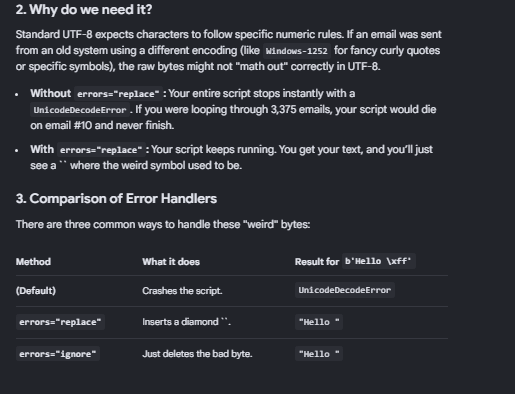

In [16]:
print(body)

I am using smtplib and imaplib and email built in libraries to write python scripts to send and read mails : with the gmails, It is fun learning this, maybe in future i can automate reading and sending mails and it can save me and my collegues so much time, and in that time we can do something productive, as i believe therre are some fix emails which are m,eant to be sent on daily basis on fix times regarding updates and based on some fixed excel files? so i can write some py scripts to analyze those data and write a mail based on that and send it, yipeeee

